# Macroeconomic Analysis of Kyrgyzstan

This project analyzes the relationship between:
- USD/KGS exchange rate
- inflation
- average monthly salary

using publicly available macroeconomic data from Kyrgyzstan (2010–2024).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works")

Everything works


## Exchange Rate Data

In [2]:
excel_file = pd.ExcelFile("../data/exchange_rates.xls")

excel_file.sheet_names

['2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025',
 '2026']

In [3]:
all_sheets = []

for sheet in excel_file.sheet_names:
    df = pd.read_excel(
        "../data/exchange_rates.xls",
        sheet_name=sheet
    )

    all_sheets.append(df)

exchange = pd.concat(all_sheets)

exchange.head()

,дата*,USD,EUR,RUB,KZT,CNY
0,2010-01-01 00:00:00,44.0917,NaN,NaN,NaN,NaN
1,2010-01-04 00:00:00,44.0917,NaN,NaN,NaN,NaN
2,2010-01-05 00:00:00,44.0917,NaN,NaN,NaN,NaN
3,2010-01-06 00:00:00,44.0917,NaN,NaN,NaN,NaN
4,2010-01-07 00:00:00,44.0917,NaN,NaN,NaN,NaN


In [4]:
exchange = exchange.dropna(subset=["USD"])

exchange = exchange[["дата*", "USD"]]

exchange.head()

,дата*,USD
0,2010-01-01 00:00:00,44.0917
1,2010-01-04 00:00:00,44.0917
2,2010-01-05 00:00:00,44.0917
3,2010-01-06 00:00:00,44.0917
4,2010-01-07 00:00:00,44.0917


In [5]:
exchange["дата*"] = pd.to_datetime(exchange["дата*"])

exchange.info()

<class 'pandas.DataFrame'>
Index: 5985 entries, 0 to 146
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   дата*   5985 non-null   datetime64[us]
 1   USD     5985 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.3 KB


## Yearly Exchange Rate Aggregation

In [6]:
exchange["year"] = exchange["дата*"].dt.year

yearly_exchange = exchange.groupby("year")["USD"].mean().reset_index()

yearly_exchange.columns = ["year", "avg_usd_kgs"]

yearly_exchange.head()

,year,avg_usd_kgs
0,2010,45.988358
1,2011,46.135918
2,2012,47.005010
3,2013,48.438570
4,2014,53.662815


In [7]:
yearly_exchange.to_csv("../data/exchange_rates_clean.csv", index=False)

## Inflation Data

In [8]:
inflation = pd.read_excel("../data/inflation.xlsx", header=3)

inflation.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,Көрсөткүчтөрдүн аталыштары,Наименование показателей,Items,2006.000000,2007.000000,2008.000000,2009.000000,2010.000000,2011.000000,2012.000000,...,2015.000000,2016.000000,2017.000000,2018.000000,2019.00,2020.000000,2021.000000,2022.000000,2023.000000,2024.000000
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Кыргыз Республикасы,Кыргызская Республика,Kyrgyz Republic,105.552318,110.230335,124.519751,106.827964,107.996472,116.587211,102.768442,...,106.503318,100.388838,103.175310,101.542661,101.13,106.322554,111.905040,113.922909,110.799008,105.020509
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Баткен облусу,Баткенская область,Batken oblast,104.511286,110.682859,121.470061,110.949104,116.842333,121.018398,110.006871,...,106.323310,100.238082,104.094759,100.222682,102.50,107.865451,113.137602,113.590564,111.270370,104.916384


In [9]:
kyrgyzstan_inflation = inflation.iloc[[2]]

kyrgyzstan_inflation

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
2,Кыргыз Республикасы,Кыргызская Республика,Kyrgyz Republic,105.552318,110.230335,124.519751,106.827964,107.996472,116.587211,102.768442,...,106.503318,100.388838,103.17531,101.542661,101.13,106.322554,111.90504,113.922909,110.799008,105.020509


In [10]:
inflation_long = kyrgyzstan_inflation.melt()

inflation_long.head(15)

,variable,value
0,Unnamed: 0,Кыргыз Республикасы
1,Unnamed: 1,Кыргызская Республика
2,Unnamed: 2,Kyrgyz Republic
3,Unnamed: 3,105.552318
4,Unnamed: 4,110.230335
5,Unnamed: 5,124.519751
6,Unnamed: 6,106.827964
7,Unnamed: 7,107.996472
8,Unnamed: 8,116.587211
9,Unnamed: 9,102.768442


In [11]:
years = list(range(2006, 2025))

years

[2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [12]:
inflation_clean = pd.DataFrame({
    "year": years,
    "inflation_index": inflation_long["value"][3:].values
})

inflation_clean.head()

,year,inflation_index
0,2006,105.552318
1,2007,110.230335
2,2008,124.519751
3,2009,106.827964
4,2010,107.996472


In [13]:
inflation_clean.to_csv("../data/inflation_clean.csv", index=False)

## Salary Data

In [14]:
salary = pd.read_excel("../data/salary.xlsx", header=3)

salary.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,Көрсөткүчтөрдүн аталыштары,Наименование показателей,Items,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,...,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Кыргыз Республикасы,Кыргызская Республика,Kyrgyz Republic,3270.0,3866.0,5378.0,6161.0,7189.0,9304.0,10726.0,...,13483.0,14847.0,15670.0,16427.0,17232.0,18940.0,19330.0,26540.0,31604.0,36047.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Баткен облусу,Баткенская область,Batken oblast,2266.0,2658.0,3703.0,4012.0,4651.0,6531.0,8206.0,...,9468.0,10093.0,10486.0,11026.0,11583.0,13017.0,13010.0,20439.0,25554.0,26662.0


In [15]:
kyrgyzstan_salary = salary.iloc[[2]]

kyrgyzstan_salary

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
2,Кыргыз Республикасы,Кыргызская Республика,Kyrgyz Republic,3270.0,3866.0,5378.0,6161.0,7189.0,9304.0,10726.0,...,13483.0,14847.0,15670.0,16427.0,17232.0,18940.0,19330.0,26540.0,31604.0,36047.0


In [16]:
salary_long = kyrgyzstan_salary.melt()

salary_long.head(15)

,variable,value
0,Unnamed: 0,Кыргыз Республикасы
1,Unnamed: 1,Кыргызская Республика
2,Unnamed: 2,Kyrgyz Republic
3,Unnamed: 3,3270.0
4,Unnamed: 4,3866.0
5,Unnamed: 5,5378.0
6,Unnamed: 6,6161.0
7,Unnamed: 7,7189.0
8,Unnamed: 8,9304.0
9,Unnamed: 9,10726.0


In [17]:
salary_clean = pd.DataFrame({
    "year": years,
    "avg_salary_kgs": salary_long["value"][3:].values
})

salary_clean.head()

,year,avg_salary_kgs
0,2006,3270.0
1,2007,3866.0
2,2008,5378.0
3,2009,6161.0
4,2010,7189.0


In [18]:
salary_clean.to_csv("../data/salary_clean.csv", index=False)

## Merge Datasets

In [19]:
final_data = yearly_exchange.merge(
    inflation_clean,
    on="year"
)

final_data = final_data.merge(
    salary_clean,
    on="year"
)

final_data.head()

,year,avg_usd_kgs,inflation_index,avg_salary_kgs
0,2010,45.988358,107.996472,7189.0
1,2011,46.135918,116.587211,9304.0
2,2012,47.005010,102.768442,10726.0
3,2013,48.438570,106.618067,11341.0
4,2014,53.662815,107.534247,12285.0


## Data Validation

In [20]:
final_data["inflation_index"] = pd.to_numeric(final_data["inflation_index"])

final_data["avg_salary_kgs"] = pd.to_numeric(final_data["avg_salary_kgs"])

In [21]:
final_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             15 non-null     int32  
 1   avg_usd_kgs      15 non-null     float64
 2   inflation_index  15 non-null     float64
 3   avg_salary_kgs   15 non-null     float64
dtypes: float64(3), int32(1)
memory usage: 552.0 bytes


## Exploratory Data Analysis

## Descriptive Statistics Summary

In [22]:
final_data.describe()

,year,avg_usd_kgs,inflation_index,avg_salary_kgs
count,15.000000,15.000000,15.000000,15.000000
mean,2017.000000,66.949319,106.814306,17397.666667
std,4.472136,15.540457,4.813266,8203.464048
min,2010.000000,45.988358,100.388838,7189.000000
25%,2013.500000,51.050693,102.971876,11813.000000
50%,2017.000000,68.865622,106.503318,15670.000000
75%,2020.500000,80.743459,109.397740,19135.000000
max,2024.000000,87.860521,116.587211,36047.000000


In [23]:
## Correlation analysis

In [24]:
final_data.corr(numeric_only=True)

,year,avg_usd_kgs,inflation_index,avg_salary_kgs
year,1.000000,0.975851,0.026982,0.926515
avg_usd_kgs,0.975851,1.000000,0.047180,0.881329
inflation_index,0.026982,0.047180,1.000000,0.109459
avg_salary_kgs,0.926515,0.881329,0.109459,1.000000


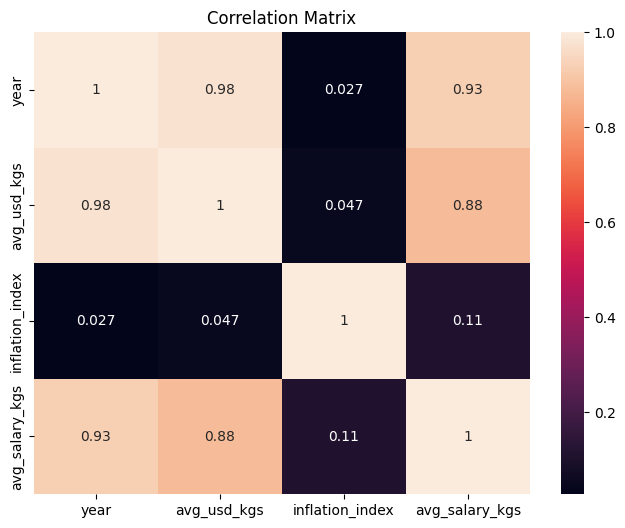

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    final_data.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

## Insight

The correlation analysis reveals a strong positive relationship between the USD/KGS exchange rate and average salary levels in Kyrgyzstan. Both indicators show a steady upward trend over time. 

Inflation demonstrates relatively weak correlations with the other variables, suggesting that inflation fluctuations were less directly associated with exchange rate and salary growth during the observed period.

### USD/KGS Exchange Rate Over Time

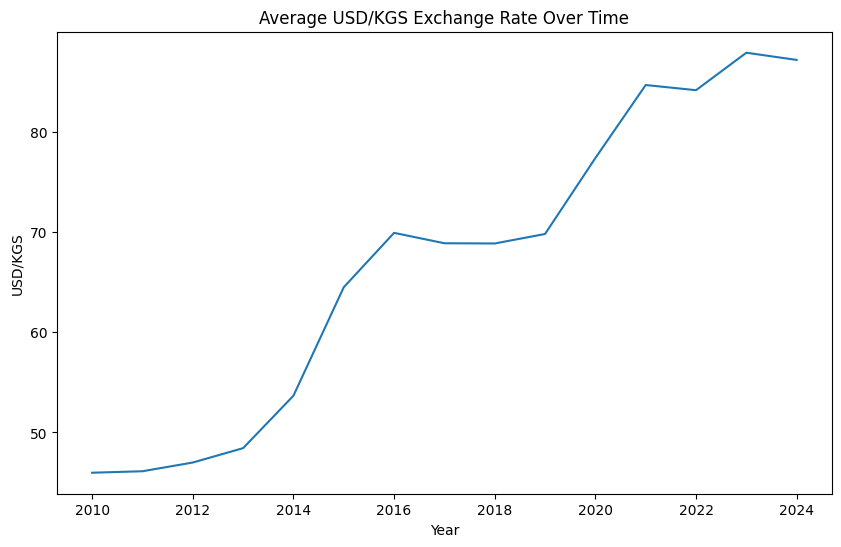

In [26]:
plt.figure(figsize=(10,6))

plt.plot(
    final_data["year"],
    final_data["avg_usd_kgs"]
)

plt.title("Average USD/KGS Exchange Rate Over Time")

plt.xlabel("Year")

plt.ylabel("USD/KGS")

plt.show()

### Insight

The graph shows a strong upward trend in the USD/KGS exchange rate from 2010 to 2024.  
The exchange rate increased from around 46 KGS per USD in 2010 to more than 87 KGS per USD in 2024.

This means that the Kyrgyz som depreciated over time against the US dollar.  
The sharpest increase occurred between 2014–2015 and again during 2020–2021.

After 2021, the exchange rate remained relatively stable at a high level, fluctuating around 85–88 KGS per USD.

## Average Salary Trend

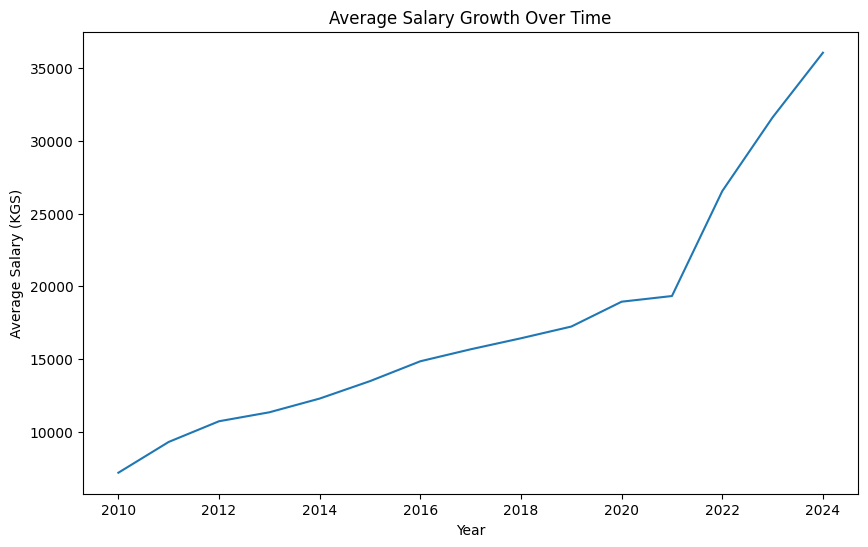

In [27]:
plt.figure(figsize=(10,6))

plt.plot(
    final_data["year"],
    final_data["avg_salary_kgs"]
)

plt.title("Average Salary Growth Over Time")

plt.xlabel("Year")

plt.ylabel("Average Salary (KGS)")

plt.show()

### Insight

The graph shows a strong upward trend in average monthly salaries in Kyrgyzstan between 2010 and 2024.

Average salaries increased from around 7,000 KGS in 2010 to more than 36,000 KGS in 2024.  
The most rapid salary growth occurred after 2021.

This trend may indicate economic growth, rising wages, inflation effects, and changes in labor market conditions over time.

## Average Inflation Trend

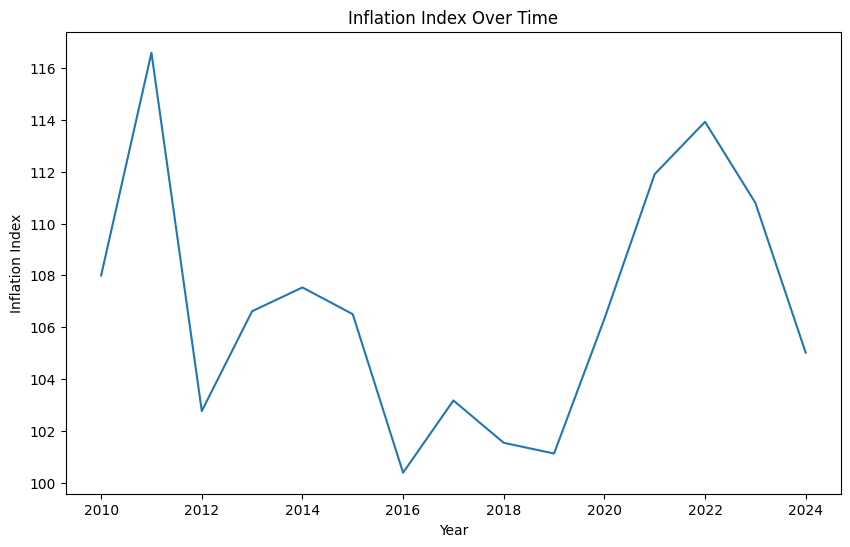

In [28]:
plt.figure(figsize=(10,6))

plt.plot(
    final_data["year"],
    final_data["inflation_index"]
)

plt.title("Inflation Index Over Time")

plt.xlabel("Year")

plt.ylabel("Inflation Index")

plt.show()

### Insight

The inflation index fluctuated over the analyzed period rather than following a steady trend.

The highest inflation levels were observed in 2011 and 2022, while lower inflation levels appeared around 2016–2019.

This indicates that inflation in Kyrgyzstan experienced periods of both acceleration and stabilization during 2010–2024.

### Relationship Between Exchange Rate and Salary

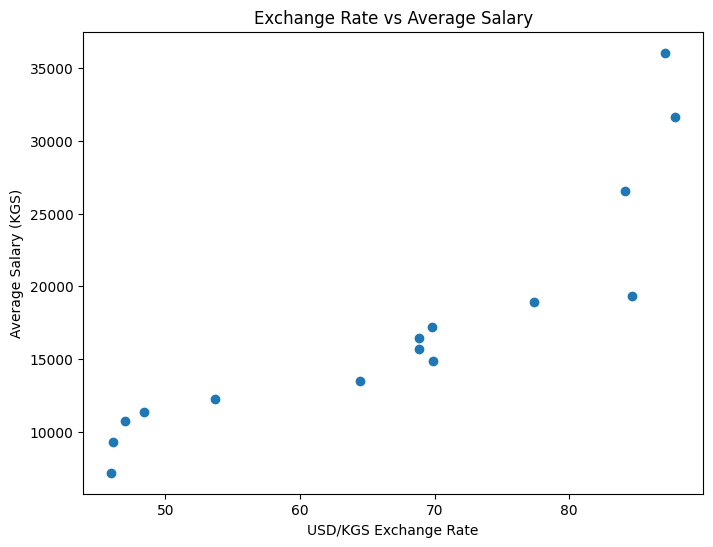

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_data["avg_usd_kgs"],
    final_data["avg_salary_kgs"]
)

plt.title("Exchange Rate vs Average Salary")
plt.xlabel("USD/KGS Exchange Rate")
plt.ylabel("Average Salary (KGS)")

plt.show()

### Insight

The scatter plot demonstrates a strong positive relationship between the USD/KGS exchange rate and average salaries in Kyrgyzstan.

Most points form an upward trend, indicating that higher exchange rates were generally associated with higher average salaries over time.

This visual pattern supports the correlation analysis, which showed a strong positive correlation between these two variables.

### Relationship Between Inflation and Salary

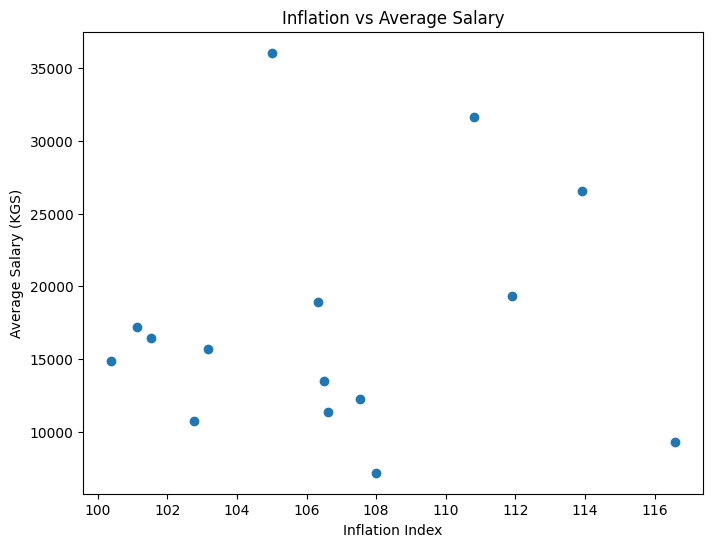

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_data["inflation_index"],
    final_data["avg_salary_kgs"]
)

plt.title("Inflation vs Average Salary")
plt.xlabel("Inflation Index")
plt.ylabel("Average Salary (KGS)")

plt.show()

### Insight

The relationship between inflation and average salaries appears relatively weak and inconsistent.

Unlike the exchange rate relationship, the points are more widely scattered and do not form a clear linear pattern.

This suggests that salary growth in Kyrgyzstan was not strongly associated with changes in the inflation index during the analyzed period.

# Final Conclusions

1. The USD/KGS exchange rate showed a strong upward trend between 2010 and 2024.

2. Average monthly salaries increased significantly during the analyzed period.

3. Inflation fluctuated over time without a stable long-term trend.

4. Correlation analysis showed a strong positive relationship between exchange rates and salaries.

5. The relationship between inflation and salaries appeared relatively weak.

## Export Final Dataset

In [31]:
final_data.to_csv("../data/final_macro_data.csv", index=False)